# 02 · Delayed-electron pile-up walk-through

            This is the canonical end-to-end DE notebook. It reproduces the contents of
            the legacy `DEMO.ipynb` / `Run_test.ipynb` on top of the refactored
            :class:`relics_de_sim.Pipeline`.

            Stages:

            1. Muon tracks  → dense interpolation
            2. Delayed electrons (power-law dt + Gaussian xy)
            3. Pile-up grouping (n=2..7)
            4. S2 pattern simulation (light, pe, area)
            5. CNN position reconstruction
            6. Reconstructed-position S2 pattern
            7. Pattern likelihood + space-time correlation

In [1]:
# Auto-discover the package even if the notebook is launched from outside the repo.
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

In [2]:
from relics_de_sim import DESimConfig, Pipeline
cfg = DESimConfig.from_yaml('../configs/de_sim.yaml')
print('dead_time_s:', cfg.simulation.dead_time_s)
print('pile_up_orders:', cfg.simulation.pile_up_orders)

dead_time_s: 0.002
pile_up_orders: [2, 3, 4, 5, 6, 7]


## Stage 1 – Load muons

In [4]:
from pathlib import Path
files_per_batch = 3
muon_files = [Path(cfg.paths.muon_track_dir) / f'muon_track.{i}.npy'
                for i in range(files_per_batch)]
pipe = Pipeline(cfg, rng=np.random.default_rng(42))
pipe.load_muon_tracks(muon_files)
print(f'simulated time range: {pipe.time_range_s/3600:.2f} h')
print(f'dead-time ratio (DE survival fraction): we estimate per-config')

Reading muon files: 100%|██████████| 3/3 [00:00<00:00, 201.20it/s]


simulated time range: 0.27 h
dead-time ratio (DE survival fraction): we estimate per-config


## Stage 2 – Delayed electrons

51_063_626 delayed electrons survived the fiducial cut
  rate: 33510.6 / s


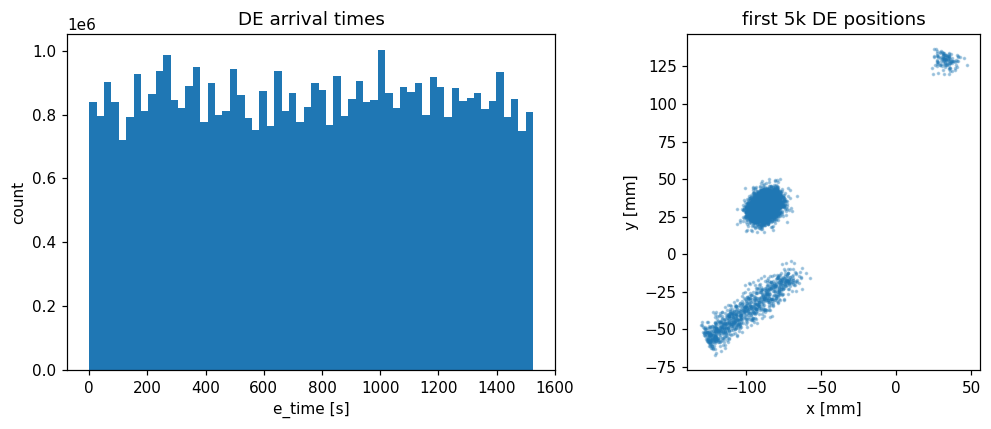

In [ ]:
pipe.simulate_delayed_electrons()
n_de = len(pipe.delayed_electron)
print(f'{n_de:_} delayed electrons survived the fiducial cut')
print(f'  rate: {n_de / pipe.time_range_s:.1f} / s')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(pipe.delayed_electron['e_time'], bins=60)
axes[0].set_xlabel('e_time [s]'); axes[0].set_ylabel('count')
axes[1].scatter(pipe.delayed_electron['xd'][:5000],
                pipe.delayed_electron['yd'][:5000], s=2, alpha=0.3)
axes[1].set_xlabel('x [mm]'); axes[1].set_ylabel('y [mm]'); axes[1].set_aspect('equal')
axes[0].set_title('DE arrival times')
axes[1].set_title('first 5k DE positions')
plt.tight_layout(); plt.show()

## Stage 3 – Pile-up grouping (n = 2..7)

In [ ]:
pipe.simulate_pile_up_patterns()
for n, res in zip(pipe.pile_up_orders, pipe.pile_up_results):
    print(f'  n={n}: {len(res.pe_by_area)} surviving events')

  n=2: 62481 surviving events
  n=3: 353292 surviving events
  n=4: 232835 surviving events
  n=5: 97874 surviving events
  n=6: 43285 surviving events
  n=7: 20521 surviving events


## Stage 4-5 – Position reconstruction + scoring

In [ ]:
try:
    pipe.recon_position_de()
    pipe.score()
    for n, coef, st in zip(pipe.pile_up_orders, pipe.pile_up_pattern_coef, pipe.pile_up_st_cor):
        if len(coef):
            print(f'  n={n}: <pattern_coef>={coef.mean():.2f}, <st_cor>={st.mean():.2e}')
except ImportError as exc:
    print('Skipping CNN inference (torch unavailable):', exc)

/home/leiyang/TPC_DE_SIm-main/relics_de_sim/recon.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = self._torch.load(checkpoint_path, map_location=self.device)
s

  n=2: <pattern_coef>=-78.43, <st_cor>=2.76e+10
  n=3: <pattern_coef>=-82.34, <st_cor>=5.58e+11
  n=4: <pattern_coef>=-90.64, <st_cor>=1.94e+14
  n=5: <pattern_coef>=-102.74, <st_cor>=4.01e+13
  n=6: <pattern_coef>=-115.34, <st_cor>=4.00e+11
  n=7: <pattern_coef>=-127.65, <st_cor>=1.54e+11


## Stage 6 – Save output

            ``Pipeline.save`` writes the standardised ``de_result.npz`` + ``meta.json``
            (see :mod:`relics_de_sim.io`).

In [ ]:
out = pipe.save('outputs/de_sim/notebook_demo')
print('wrote', out)

wrote outputs/de_sim/notebook_demo
